# Analyse Gromacs mdp files

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Update font size for graphics
plt.rcParams.update({"font.size": 20})

In [4]:
df = pd.read_csv("../data/gromacs_mdp_files_info.tsv", sep="\t")
print(df.shape)
df.head()

(5454, 8)


,dataset_origin,dataset_id,dt,nsteps,temperature,barostat,thermostat,filename
0,osf,2ah8r,0.001,2500000.0,303.15,NaN,berendsen,step6.2_equilibration.mdp
1,osf,2ah8r,0.002,5000000.0,303.15,berendsen,berendsen,step6.4_equilibration.mdp
2,osf,2ah8r,0.001,2500000.0,303.15,berendsen,berendsen,step6.3_equilibration.mdp
3,osf,2ah8r,0.002,5000000.0,303.15,berendsen,berendsen,step6.6_equilibration.mdp
4,osf,2ah8r,0.002,100000000.0,303.15,Parrinello-Rahman,Nose-Hoover,step7_production.mdp


## Temperature

### Temperature distribution

count    5148.000000
mean      306.408012
std        32.336026
min         0.000000
25%       300.000000
50%       310.000000
75%       310.000000
max      1500.000000
Name: temperature, dtype: float64


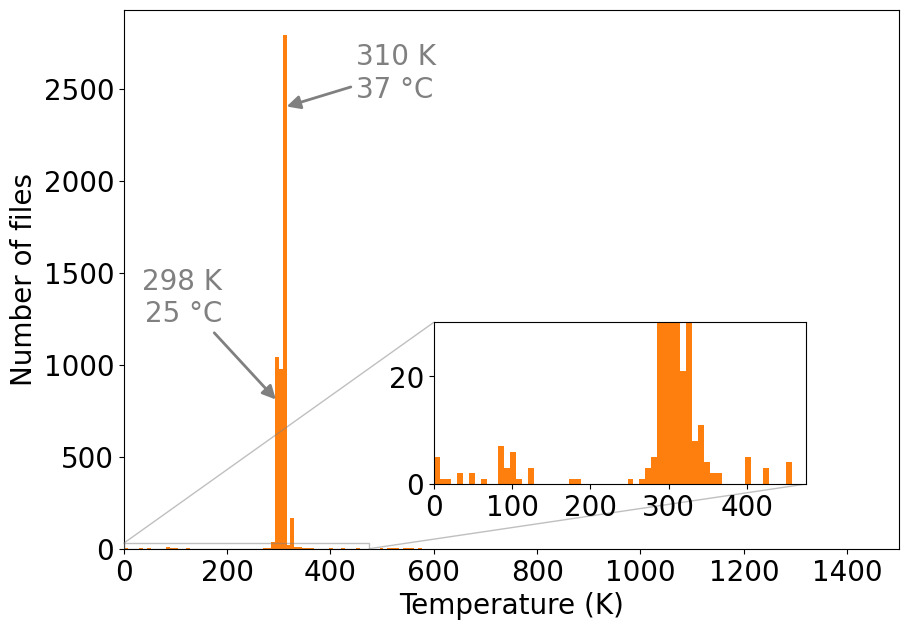

In [5]:
print(df["temperature"].describe())

bins=200

fig, ax = plt.subplots(figsize=(10,7))
ax.hist(df["temperature"], 
         bins=bins,
         color="tab:orange")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Number of files")
ax.set_xlim(0, max(df["temperature"]))
ax.annotate("310 K\n37 °C", xy=(310, 2400), xytext=(450, 2750), color="gray",
             arrowprops={"arrowstyle":"-|>", "lw":2, "color":"gray", "connectionstyle":"arc3"}, 
             horizontalalignment="left", verticalalignment="top")
ax.annotate("298 K\n25 °C", xy=(298, 800), xytext=(190, 1200), color="gray",
             arrowprops={"arrowstyle":"-|>", "lw":2, "color":"gray"}, 
             horizontalalignment="right", verticalalignment="bottom")

plt.savefig("gromacs_mdp_temp_histogram.png", dpi=300, bbox_inches="tight")
plt.savefig("gromacs_mdp_temp_histogram.svg", bbox_inches="tight")

axin = ax.inset_axes([0.40, 0.12, 0.48, 0.3])
axin.hist(df["temperature"], 
         bins=bins,
         color="tab:orange")
axin.set_xlim(0, 475)
axin.set_xticks(range(0, 450, 100))
axin.set_ylim(0, 30)

ax.indicate_inset_zoom(axin)

fig.savefig("gromacs_mdp_temp_histogram_with_inset.png", dpi=300, bbox_inches="tight")
fig.savefig("gromacs_mdp_temp_histogram_with_inset.svg", bbox_inches="tight")

### Low temperatures

In [6]:
df.query("temperature < 50")

,dataset_origin,dataset_id,dt,nsteps,temperature,barostat,thermostat,filename
4452,zenodo,6056060,0.0020,10000.0,30.0,Parrinello-Rahman,v-rescale,masterclass/mdout.mdp
4453,zenodo,6056060,0.0020,10000.0,30.0,Parrinello-Rahman,v-rescale,masterclass/npt.mdp
4692,figshare,3408676,0.0010,1000000.0,15.0,NaN,NaN,Validation/WaterHexamer/gmx/run.mdp
4710,figshare,7370684,0.0020,5000.0,0.0,no,v-rescale,md_files/2-MD-runs/mdp/1_grompp_minimisation.mdp
5157,figshare,10269416,0.0005,10000000.0,10.0,Parrinello-Rahman,nose-hoover,input_files/MD/production.mdp
5158,figshare,10269416,0.0005,60000000.0,3.0,Parrinello-Rahman,nose-hoover,input_files/MD/production_REMD.mdp
5241,figshare,8846045,0.0300,10000.0,0.0,berendsen,Berendsen,Tutorial/mdp/2_npt.mdp
5243,figshare,8846045,0.0300,1000000.0,0.0,berendsen,Berendsen,Tutorial/mdp/3_run.mdp
5244,figshare,8846045,0.0300,5000.0,0.0,no,Berendsen,Tutorial/mdp/2_nvt.mdp


Dataset [figshare/10269416](https://figshare.com/articles/dataset/Adding_Anisotropy_to_the_Standard_Quasi-Harmonic_Approximation_Still_Fails_in_Several_Ways_to_Capture_Organic_Crystal_Thermodynamics/10269416) at 10 K:

> Adding Anisotropy to the Standard Quasi-Harmonic Approximation Still Fails in Several Ways to Capture Organic Crystal Thermodynamics

### Datasets around 100 K

In [7]:
df.query("temperature > 80").query("temperature < 120")

,dataset_origin,dataset_id,dt,nsteps,temperature,barostat,thermostat,filename
37,osf,82n73,0.0020,50000.0,100.0,no,Berendsen,Molecular Dynamics/Standard Operating Procedur...
41,osf,82n73,0.0020,250000.0,100.0,no,V-rescale,Molecular Dynamics/Standard Operating Procedur...
52,osf,82n73,0.0020,50000.0,100.0,no,Berendsen,Molecular Dynamics/Standard Operating Procedur...
54,osf,82n73,0.0020,250000.0,100.0,no,V-rescale,Molecular Dynamics/Standard Operating Procedur...
77,osf,82n73,0.0020,50000.0,100.0,no,Berendsen,Molecular Dynamics/Standard Operating Procedur...
79,osf,82n73,0.0020,250000.0,100.0,no,V-rescale,Molecular Dynamics/Standard Operating Procedur...
312,zenodo,4106413,0.0020,5000000.0,110.0,no,nose-hoover,neon.mdp
362,zenodo,3236015,0.0020,5000000.0,87.3,no,Berendsen,md.mdp
2450,zenodo,4608014,0.0050,100000000.0,87.3,no,v-rescale,grompp.mdp
2900,zenodo,4607786,0.0050,100000000.0,87.3,no,v-rescale,grompp.mdp


Mostly simulations of Argon, Neon, LJ fluid and proteins for SAXS experiments

### High temperatures

In [8]:
df.query("temperature > 1000")

,dataset_origin,dataset_id,dt,nsteps,temperature,barostat,thermostat,filename
4761,figshare,2267512,0.001,6000000.0,1500.0,no,V-rescale,6P_crystal_reproduction_files/reproduction_fil...


Dataset [figshare/2267512](https://figshare.com/articles/dataset/Growth_and_Characterization_of_Molecular_Crystals_of_i_para_i_Sexiphenyl_by_All_Atom_Computer_Simulations/2267512) at 1500 K:

> Growth and Characterization of Molecular Crystals of para-Sexiphenyl by All-Atom Computer Simulations

## Simulation time

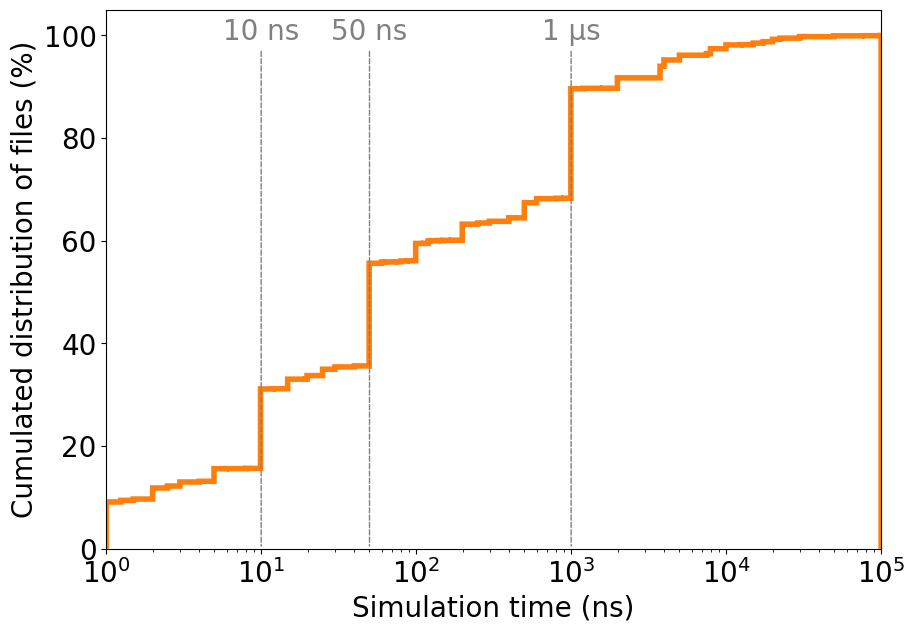

In [9]:
# dt is in ps
# https://manual.gromacs.org/documentation/current/user-guide/mdp-options.html#mdp-dt
df["time"] = df["dt"] * df["nsteps"] / 1000
# in ns
# 1 µs = 1 000 ns

logbins = np.geomspace(df["time"].min()+1, df["time"].max(), 1_000)

fig, ax = plt.subplots(figsize=(10,7))
values, bins, _ = ax.hist(
    df["time"], 
    bins=logbins,
    color="tab:orange", linewidth=4,
    histtype="step", cumulative=True, density=True
)
ax.set_xlabel("Simulation time (ns)")
ax.set_ylabel("Cumulated distribution of files (%)")
ax.set_yticks(np.arange(0, 1.1, 0.2), [f"{value:.0f}" for value in np.arange(0, 1.1, 0.2)*100])
ax.set_xscale("log")
ax.set_xlim(1, df["time"].max())
ax.annotate("10 ns", xy=(10, 0), xytext=(10, 0.98), color="gray",
             arrowprops={"arrowstyle":"-", "linestyle":"--", "lw":1, "color":"gray"}, 
             horizontalalignment="center", verticalalignment="bottom")
ax.annotate("50 ns", xy=(50, 0), xytext=(50, 0.98), color="gray",
             arrowprops={"arrowstyle":"-", "linestyle":"--", "lw":1, "color":"gray"}, 
             horizontalalignment="center", verticalalignment="bottom")
ax.annotate("1 µs", xy=(1000, 0), xytext=(1000, 0.98), color="gray",
             arrowprops={"arrowstyle":"-", "linestyle":"--", "lw":1, "color":"gray"}, 
             horizontalalignment="center", verticalalignment="bottom")
fig.savefig("gromacs_mdp_simulation_time.png", dpi=300, bbox_inches="tight")
fig.savefig("gromacs_mdp_simulation_time.svg", bbox_inches="tight")

In [10]:
# Simulations above 50 µs
df.query("time > 50_000")

,dataset_origin,dataset_id,dt,nsteps,temperature,barostat,thermostat,filename,time
202,osf,a43z2,0.030,2.500000e+09,310.0,parrinello-rahman,v-rescale,hGBP1 dimer Martini-MD/cg_md_dimer_traj.mdp,75000.0
359,zenodo,4451274,0.002,5.000000e+10,310.0,Berendsen,No,SARS-COV2_spike_simulations_Dform_Gform/md.mdp,100000.0
3204,zenodo,846428,0.020,5.000000e+09,315.0,Parrinello-rahman,v-rescale,md.mdp,100000.0


## Thermostat & barostat

In [11]:
print(df[ df["thermostat"].isna() ].shape[0])
df[ df["thermostat"].isna() ].head()

630


,dataset_origin,dataset_id,dt,nsteps,temperature,barostat,thermostat,filename,time
5,osf,2ah8r,NaN,5000.0,NaN,NaN,NaN,step6.0_minimization.mdp,NaN
14,osf,82n73,NaN,5000.0,NaN,NaN,NaN,Research Projects/HIV gp41 TMD - Biophysical J...,NaN
22,osf,82n73,NaN,5000.0,NaN,NaN,NaN,Research Projects/HIV GP41 MPER-TMD-CT JACS 20...,NaN
27,osf,82n73,NaN,5000000.0,NaN,NaN,NaN,Research Projects/IAPP(20-29) + Small Molecule...,NaN
29,osf,82n73,NaN,50000.0,NaN,NaN,NaN,Research Projects/IAPP(20-29) + Small Molecule...,NaN


In [12]:
# Clean barostat and thermostat names
thermostats = {
    "berendsen": "Berendsen",
    "nosehoover": "Nose-Hoover",
    "vrescale": "V-rescale",
    "no": "No temp."
}
barostats = {
    "berendsen": "Berendsen",
    "parrinellorahman": "Parrinello-Rahman",
    "no": "No pressure"
}
def clean_thermostat_barostat(value, conversion_dict):
    if not type(value) is str:
        return None
    raw_str = value.lower().lower().replace("-", "").replace("_", "")
    return conversion_dict.get(raw_str, None)

df["thermostat"] = df["thermostat"].apply(lambda x: clean_thermostat_barostat(x, thermostats))
df["barostat"] = df["barostat"].apply(lambda x: clean_thermostat_barostat(x, barostats))
df = df.dropna(subset=["thermostat", "barostat"])

print(f"Remaining files: {df.shape[0]}")

Remaining files: 4763


### With pySankey

https://github.com/Pierre-Sassoulas/pySankey

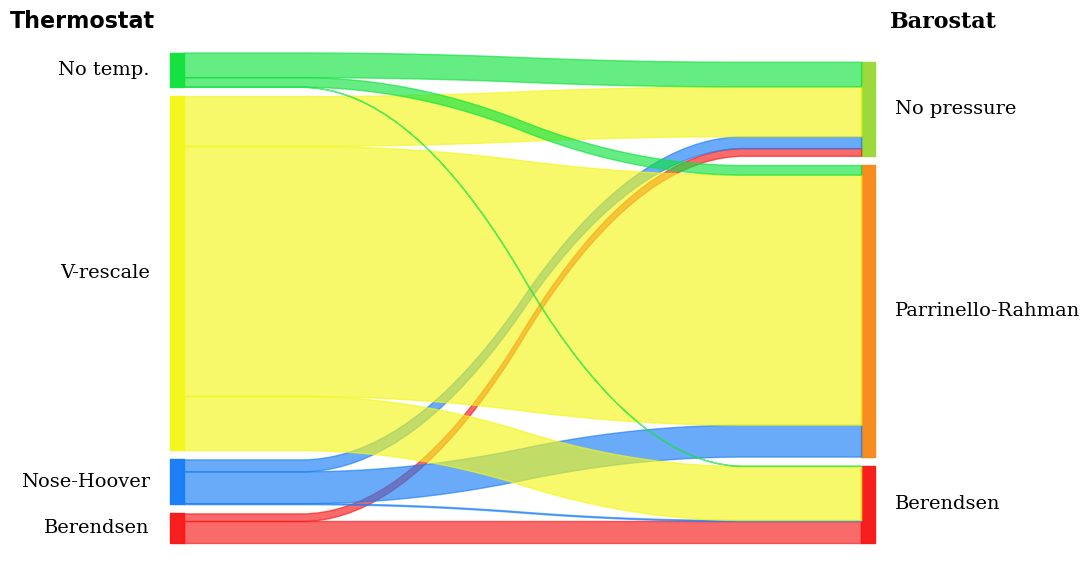

In [16]:
from pysankey import sankey

colorDict = {
    'Berendsen':'#f71b1b',
    'Nose-Hoover':'#1b7ef7',
    'V-rescale':'#f3f71b',
    'No temp.':'#12e23f',
    'Parrinello-Rahman':'#f78c1b',
    'No pressure':'#9BD937'
}

plt.rcParams.update({'font.family':'sans-serif'})
fig, ax = plt.subplots(figsize=(10,7))
ax = sankey(
    df['thermostat'], df['barostat'], aspect=10, colorDict=colorDict,
    leftLabels=['Berendsen','Nose-Hoover','V-rescale','No temp.'],
    rightLabels=['Berendsen','Parrinello-Rahman','No pressure'],
    fontsize=14
)
plt.figtext(0.00, 0.88, "Thermostat", fontsize=16, fontweight="bold", fontfamily="sans-serif")
plt.figtext(0.88, 0.88, "Barostat", fontsize=16, fontweight="bold")

fig.savefig("gromacs_mdp_thermostat_barostat.png", dpi=300, bbox_inches="tight")
fig.savefig("gromacs_mdp_thermostat_barostat.svg", bbox_inches="tight")

## Watermark

In [17]:
%load_ext watermark
%watermark --python --machine
print("")
# Versions for jupyterlab, imported packages and watermark itself
%watermark --packages jupyterlab,pysankey --iversions --watermark
# Name of conda environment
%watermark --conda

Python implementation: CPython
Python version       : 3.9.13
IPython version      : 8.5.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 5.15.0-48-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 8
Architecture: 64bit


jupyterlab: 3.4.8
pysankey  : unknown

pandas    : 1.5.0
matplotlib: 3.5.3
numpy     : 1.23.3
plotly    : 5.10.0

Watermark: 2.3.1

conda environment: mdws

